# 7. 마케팅정보 (마케팅 정보) EDA

카테고리 7 = **회사→고객 마케팅 접촉(노출) 건수**. 64개 컬럼(27개 상수). 라벨은 회원정보에서 조인.
※ 다른 카테고리(고객 행동)와 달리 **회사가 고객에게 건 접촉**이라, "회사가 이 고객을 어떻게 타깃팅하는가"를 반영 → 세그먼트의 대리 신호가 될 수 있으나 **누수(타깃팅이 세그먼트 기반이면)** 주의.

**컬럼 구조**: `컨택건수_{상품}_{채널}_{기간}`. 상품=카드론/CA/리볼빙/이용유도/신용발급/보험/부대서비스/포인트소진/채권(추심)/FDS, 채널=TM/LMS/EM/청구서/인터넷/당사앱, 기간=B0M/R6M. + 캠페인접촉건수·일수_R12M(구간 문자열).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family']='Malgun Gothic'; plt.rcParams['axes.unicode_minus']=False
pd.set_option('display.max_columns',200); pd.set_option('display.width',220)
import glob, os
ROOT = os.path.abspath(os.path.join(os.getcwd(),'..')) if os.path.basename(os.getcwd())=='eda' else os.getcwd()
MONTH='201812'; SEG_ORDER=['A','B','C','D','E']
SEG_COLORS={'A':'#d1495b','B':'#edae49','C':'#66a182','D':'#2e4057','E':'#8d96a3'}
print('ROOT =', ROOT)

ROOT = C:\Users\82109\Desktop\DACON


## 1. 데이터 로드 (201812 마케팅) + 라벨 조인

In [2]:
f7 = glob.glob(os.path.join(ROOT,'train','7.*',f'{MONTH}_*.parquet'))[0]
df = pd.read_parquet(f7)
lbl = pd.read_parquet(glob.glob(os.path.join(ROOT,'train','1.*',f'{MONTH}_*.parquet'))[0], columns=['ID','Segment'])
df = df.merge(lbl, on='ID', how='left')
assert df['Segment'].notna().all()
print('shape:', df.shape); df.head(3)

shape: (400000, 65)


,기준년월,ID,컨택건수_카드론_TM_B0M,컨택건수_리볼빙_TM_B0M,컨택건수_CA_TM_B0M,컨택건수_이용유도_TM_B0M,컨택건수_신용발급_TM_B0M,컨택건수_부대서비스_TM_B0M,컨택건수_포인트소진_TM_B0M,컨택건수_보험_TM_B0M,컨택건수_카드론_LMS_B0M,컨택건수_CA_LMS_B0M,컨택건수_리볼빙_LMS_B0M,컨택건수_이용유도_LMS_B0M,컨택건수_카드론_EM_B0M,컨택건수_CA_EM_B0M,컨택건수_리볼빙_EM_B0M,컨택건수_이용유도_EM_B0M,컨택건수_카드론_청구서_B0M,컨택건수_CA_청구서_B0M,컨택건수_리볼빙_청구서_B0M,컨택건수_이용유도_청구서_B0M,컨택건수_카드론_인터넷_B0M,컨택건수_CA_인터넷_B0M,컨택건수_리볼빙_인터넷_B0M,컨택건수_이용유도_인터넷_B0M,컨택건수_카드론_당사앱_B0M,컨택건수_CA_당사앱_B0M,컨택건수_리볼빙_당사앱_B0M,컨택건수_이용유도_당사앱_B0M,컨택건수_카드론_TM_R6M,컨택건수_CA_TM_R6M,컨택건수_리볼빙_TM_R6M,컨택건수_이용유도_TM_R6M,컨택건수_신용발급_TM_R6M,컨택건수_부대서비스_TM_R6M,컨택건수_포인트소진_TM_R6M,컨택건수_보험_TM_R6M,컨택건수_카드론_LMS_R6M,컨택건수_CA_LMS_R6M,컨택건수_리볼빙_LMS_R6M,컨택건수_이용유도_LMS_R6M,컨택건수_카드론_EM_R6M,컨택건수_CA_EM_R6M,컨택건수_리볼빙_EM_R6M,컨택건수_이용유도_EM_R6M,컨택건수_카드론_청구서_R6M,컨택건수_CA_청구서_R6M,컨택건수_리볼빙_청구서_R6M,컨택건수_이용유도_청구서_R6M,컨택건수_카드론_인터넷_R6M,컨택건수_CA_인터넷_R6M,컨택건수_리볼빙_인터넷_R6M,컨택건수_이용유도_인터넷_R6M,컨택건수_카드론_당사앱_R6M,컨택건수_CA_당사앱_R6M,컨택건수_리볼빙_당사앱_R6M,컨택건수_이용유도_당사앱_R6M,컨택건수_채권_B0M,컨택건수_FDS_B0M,컨택건수_채권_R6M,컨택건수_FDS_R6M,캠페인접촉건수_R12M,캠페인접촉일수_R12M,Segment
0,201812,TRAIN_000000,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,78,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1회 이상,1일 이상,D
1,201812,TRAIN_000001,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,15회 이상,15일 이상,E
2,201812,TRAIN_000002,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1회 이상,1일 이상,C


## 2. 컬럼 개요 — dtype / 결측 / 카디널리티

In [3]:
meta = pd.DataFrame({'dtype':df.dtypes.astype(str),'n_missing':df.isna().sum(),
    'missing_%':(df.isna().mean()*100).round(2),'nunique':df.nunique(dropna=True)})
print('상수(nun<=1):', int((meta['nunique']<=1).sum()), '/ 전체', len(meta))
meta.sort_values(['nunique']).head(35)

상수(nun<=1): 27 / 전체 65


,dtype,n_missing,missing_%,nunique
기준년월,int64,0,0.0,1
컨택건수_CA_EM_R6M,int64,0,0.0,1
컨택건수_리볼빙_EM_R6M,int64,0,0.0,1
컨택건수_CA_TM_R6M,int64,0,0.0,1
컨택건수_리볼빙_청구서_R6M,int64,0,0.0,1
컨택건수_카드론_인터넷_R6M,int64,0,0.0,1
컨택건수_리볼빙_당사앱_B0M,int64,0,0.0,1
컨택건수_CA_당사앱_B0M,int64,0,0.0,1
컨택건수_카드론_당사앱_B0M,int64,0,0.0,1
컨택건수_리볼빙_인터넷_B0M,int64,0,0.0,1


### 2-1. 버릴 후보 — 상수(27개)

In [4]:
const_cols = meta.index[meta['nunique']<=1].tolist()
high_missing = meta.index[meta['missing_%']>=40].tolist()
print(f'상수 {len(const_cols)}개:', const_cols)
print(f'고결측(>=40%) {len(high_missing)}개:', high_missing)

상수 27개: ['기준년월', '컨택건수_CA_TM_B0M', '컨택건수_부대서비스_TM_B0M', '컨택건수_포인트소진_TM_B0M', '컨택건수_CA_EM_B0M', '컨택건수_리볼빙_EM_B0M', '컨택건수_카드론_청구서_B0M', '컨택건수_리볼빙_청구서_B0M', '컨택건수_카드론_인터넷_B0M', '컨택건수_CA_인터넷_B0M', '컨택건수_리볼빙_인터넷_B0M', '컨택건수_카드론_당사앱_B0M', '컨택건수_CA_당사앱_B0M', '컨택건수_리볼빙_당사앱_B0M', '컨택건수_CA_TM_R6M', '컨택건수_포인트소진_TM_R6M', '컨택건수_CA_EM_R6M', '컨택건수_리볼빙_EM_R6M', '컨택건수_리볼빙_청구서_R6M', '컨택건수_카드론_인터넷_R6M', '컨택건수_CA_인터넷_R6M', '컨택건수_리볼빙_인터넷_R6M', '컨택건수_카드론_당사앱_R6M', '컨택건수_CA_당사앱_R6M', '컨택건수_리볼빙_당사앱_R6M', '컨택건수_FDS_B0M', '컨택건수_FDS_R6M']
고결측(>=40%) 0개: []


## 3. 세그먼트별 마케팅 컨택 (상품별 접촉 강도)

회사가 세그먼트별로 어떤 상품을 미는지. 0-inflated → 평균 기준. 총 컨택량도 파생.

In [5]:
# 총 마케팅 컨택량 파생 (상수 제외 컨택건수 합)
contact_cols = [c for c in df.columns if c.startswith('컨택건수_') and c not in const_cols]
df['컨택_총합_R6M'] = df[[c for c in contact_cols if c.endswith('_R6M')]].sum(axis=1)
df['컨택_총합_B0M'] = df[[c for c in contact_cols if c.endswith('_B0M')]].sum(axis=1)

rep = [c for c in ['컨택_총합_R6M','컨택건수_이용유도_TM_R6M','컨택건수_이용유도_EM_R6M','컨택건수_카드론_TM_R6M',
                   '컨택건수_보험_TM_R6M','컨택건수_채권_R6M'] if c in df.columns]
print('=== 세그먼트별 평균 ===')
print(df.groupby('Segment')[rep].mean().reindex(SEG_ORDER).round(2).T.to_string())

=== 세그먼트별 평균 ===
Segment               A      B      C      D      E
컨택_총합_R6M         27.59  40.88  26.63  27.42  17.93
컨택건수_이용유도_TM_R6M   0.00   0.00   0.02   0.06   0.58
컨택건수_이용유도_EM_R6M  16.73  27.54  17.31  18.09   9.30
컨택건수_카드론_TM_R6M    0.40   0.75   0.84   1.01   1.00
컨택건수_보험_TM_R6M     0.08   0.29   0.08   0.08   0.08
컨택건수_채권_R6M        0.03   0.00   0.19   0.21   0.15


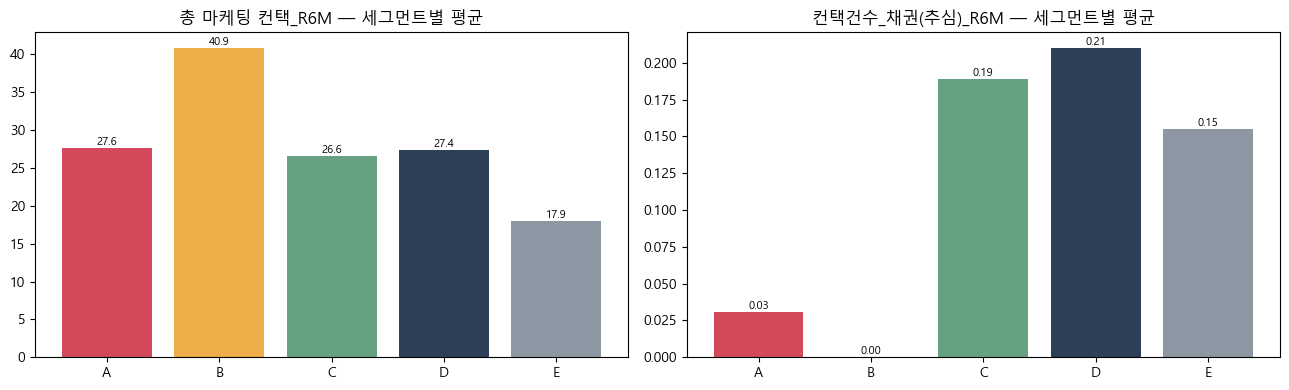

In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
m1 = df.groupby('Segment')['컨택_총합_R6M'].mean().reindex(SEG_ORDER)
ax[0].bar(SEG_ORDER, m1.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[0].set_title('총 마케팅 컨택_R6M — 세그먼트별 평균')
for i,v in enumerate(m1.values): ax[0].text(i,v,f'{v:.1f}',ha='center',va='bottom',fontsize=8)
m2 = df.groupby('Segment')['컨택건수_채권_R6M'].mean().reindex(SEG_ORDER)
ax[1].bar(SEG_ORDER, m2.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[1].set_title('컨택건수_채권(추심)_R6M — 세그먼트별 평균')
for i,v in enumerate(m2.values): ax[1].text(i,v,f'{v:.2f}',ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()

## 4. Segment를 잘 가르는 수치형 피처 랭킹 (평균 기반)

In [7]:
drop=set(const_cols)|{'기준년월'}
num_cols=[c for c in df.columns if c not in drop and c not in ('ID','Segment') and pd.api.types.is_numeric_dtype(df[c])]
print('수치형 분석 대상:', len(num_cols))
mean_=df.groupby('Segment')[num_cols].mean().reindex(SEG_ORDER).T
sep=((mean_.max(axis=1)-mean_.min(axis=1))/(df[num_cols].std()+1e-9)).sort_values(ascending=False)
mm=mean_.loc[sep.index]; mm.insert(0,'sep',sep.round(3))
print('평균 기반 분리도 상위 18:')
mm.head(18).round(2)

수치형 분석 대상: 36


평균 기반 분리도 상위 18:


Segment,sep,A,B,C,D,E
컨택건수_보험_TM_B0M,1.40,0.01,0.12,0.01,0.01,0.01
컨택건수_이용유도_청구서_B0M,1.11,0.70,0.75,0.46,0.36,0.21
컨택건수_카드론_EM_R6M,0.91,0.02,0.00,0.00,0.00,0.00
컨택_총합_R6M,0.84,27.59,40.88,26.63,27.42,17.93
컨택건수_이용유도_EM_R6M,0.78,16.73,27.54,17.31,18.09,9.30
컨택건수_이용유도_LMS_R6M,0.76,5.32,7.75,4.50,4.37,3.79
컨택건수_이용유도_청구서_R6M,0.75,3.68,3.79,2.57,2.34,1.78
컨택건수_이용유도_LMS_B0M,0.74,0.90,1.25,0.74,0.71,0.56
컨택건수_보험_TM_R6M,0.63,0.08,0.29,0.08,0.08,0.08
컨택_총합_B0M,0.62,4.72,5.58,4.37,4.44,2.72


## 5. 캠페인 접촉 (구간형) vs Segment

In [8]:
cat_cols=[c for c in ['캠페인접촉건수_R12M','캠페인접촉일수_R12M'] if c in df.columns]
for c in cat_cols:
    ct=pd.crosstab(df[c],df['Segment']).reindex(columns=SEG_ORDER,fill_value=0)
    row_pct=(ct.div(ct.sum(axis=1),axis=0)*100).round(1); out=row_pct.copy(); out['n']=ct.sum(axis=1)
    print(f'\n=== {c} : 값별 세그먼트 구성비(%) ===')
    print(out.sort_values('n',ascending=False).to_string())


=== 캠페인접촉건수_R12M : 값별 세그먼트 구성비(%) ===
Segment         A    B    C     D     E       n
캠페인접촉건수_R12M                                   
1회 이상         0.0  0.0  5.8  15.2  78.9  279785
5회 이상         0.0  0.0  3.6  12.2  84.2   63817
10회 이상        0.0  0.0  4.1  12.9  82.9   26294
15회 이상        0.0  0.0  5.0  14.2  80.7   17783
20회 이상        0.0  0.0  5.2  17.0  77.8   12321

=== 캠페인접촉일수_R12M : 값별 세그먼트 구성비(%) ===
Segment         A    B    C     D     E       n
캠페인접촉일수_R12M                                   
1일 이상         0.0  0.0  5.8  15.2  79.0  283561
5일 이상         0.0  0.0  3.6  12.0  84.4   63971
10일 이상        0.0  0.0  4.2  13.0  82.8   25822
15일 이상        0.0  0.0  5.0  15.1  79.9   20980
20일 이상        0.0  0.0  5.2  17.9  76.8    5666


## 6. 소수클래스 A / B

In [9]:
a_mean=df[df['Segment']=='A'][num_cols].mean(); b_mean=df[df['Segment']=='B'][num_cols].mean(); g_mean=df[num_cols].mean()
cmp=pd.DataFrame({'A_mean':a_mean.round(2),'B_mean':b_mean.round(2),'ALL_mean':g_mean.round(2)})
cmp['A_vs_B_absdiff']=(a_mean-b_mean).abs()
print('=== A vs B 평균 차이 큰 피처 상위 15 ===')
print(cmp.sort_values('A_vs_B_absdiff',ascending=False).head(15).to_string())

=== A vs B 평균 차이 큰 피처 상위 15 ===
                   A_mean  B_mean  ALL_mean  A_vs_B_absdiff
컨택_총합_R6M           27.59   40.88     19.78       13.288580
컨택건수_이용유도_EM_R6M    16.73   27.54     11.01       10.813272
컨택건수_이용유도_LMS_R6M    5.32    7.75      3.91        2.429012
컨택_총합_B0M            4.72    5.58      3.06        0.867284
컨택건수_이용유도_인터넷_R6M    1.27    0.75      1.18        0.515432
컨택건수_카드론_TM_R6M      0.40    0.75      0.99        0.348765
컨택건수_이용유도_LMS_B0M    0.90    1.25      0.59        0.348765
컨택건수_이용유도_EM_B0M     2.85    3.17      1.81        0.320988
컨택건수_보험_TM_R6M       0.08    0.29      0.08        0.211420
컨택건수_보험_TM_B0M       0.01    0.12      0.01        0.118827
컨택건수_이용유도_청구서_R6M    3.68    3.79      1.91        0.112654
컨택건수_카드론_TM_B0M      0.07    0.17      0.16        0.092593
컨택건수_CA_청구서_R6M      0.06    0.00      0.03        0.061728
컨택건수_이용유도_인터넷_B0M    0.18    0.12      0.15        0.054012
컨택건수_이용유도_청구서_B0M    0.70    0.75      0.24        0.052469


## 7. 요약 & 발견

### 분리력이 가장 약한 카테고리
분리도(sep)가 전부 <1.4로 8개 중 최약. 마케팅 컨택은 세그먼트를 직접 가르기보단 **회사의 타깃팅 방향**을 반영. 순서형(A→E) 아님. 27/64가 상수.

### 타깃팅 방향 (약하지만 해석 가능한 패턴)
- **총 컨택량**(`컨택_총합_R6M`): E가 최소(17.9) vs 나머지 27~41. → **E(휴면)는 적게 타깃팅됨.** 활동 고객일수록 마케팅을 더 받음.
- **이용유도 이메일**(`컨택건수_이용유도_EM_R6M`)이 컨택의 주력: B 27.5 · A/C/D ~17 · E 9.3. 활성 고소비에 이용유도 집중.
- **역방향(하위 타깃팅)**: `컨택건수_이용유도_TM`(텔레마케팅)은 **E가 최고**(0.58 vs A/B 0) — 휴면 재활성화 콜. `컨택건수_카드론_TM`은 D/E로 갈수록↑(E 1.00 vs A 0.40) — 카드론 권유는 하위 등급에.

### 채권(추심) 컨택 — A/B 건전성 재확인
`컨택건수_채권_R6M` 평균: **C/D 최고(0.19~0.21), A 0.03, B 0.00.** 추심 접촉이 A/B엔 사실상 없음 → 05(연체 0%)와 일관되게 **A/B는 건전 고객** 재확인. 추심은 오히려 C/D 중간층.

### 캠페인 접촉 = 무정보
`캠페인접촉건수/일수_R12M` 모든 구간이 기저비율(E80/D15/C5)과 거의 동일 → **세그먼트 판별에 무의미.**

### A/B & 누수 주의
B는 총 컨택·이용유도 EM을 가장 많이 받음(A 대비 총합 27.6→40.9). 보험 TM도 B 최고. 다만 전반적으로 약한 신호. ⚠️ **마케팅 타깃팅이 세그먼트 정책 기반이면 누수 가능** → 피처 사용 시 검증 필요, 우선순위 낮게.

### 전처리 메모
- **상수 27개 제거.** 0-inflated → 평균/합 파생. `컨택_총합`류 집계 피처가 개별 컨택보다 유용.
- 저정보 카테고리: 소비/잔액 대비 보조. 유지 가치는 'E 저타깃팅', '채권 컨택(C/D)', 'B 고타깃팅' 정도.

**다음 카테고리**: 8.성과정보 (증감율/추세) — 마지막.